In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation

In [ ]:
# design variables
r_1 = 0.28  # fixed link length, distance between O_1 and O_2
r_2 = 0.08 # fixed length between O_1 and A, connected to the driver
r_3 = 0.28# fixed length between A and between B
r_4 = 0.427# fixed length between B and O_2
r_DC = 0.17 # fixed distance between D and C
r_6 = 0.46 # fixed distance between A and E
r_7 = 0.52 # fixed distance between C and F
r_8 = 0.06 # fixed distance between E and F
theta_0 = 19.7 * np.pi/180 # angle between two fixed points
theta_C = 128 * np.pi/180 # angle between BDC
theta_I = 85 * np.pi/180  # angle of FEG
L_1 = 0.46 # length of the leg: DE
L_2 = 0.4 # length of the leg: EG


theta_3_init = 275 * np.pi/180
theta_4_init = 260 * np.pi/180
theta_6_init = 285 * np.pi/180
theta_7_init = 275 * np.pi/180
theta_8_init = -30 * np.pi/180
theta_f_init = 270 * np.pi/180

t_begin =  0     # start time of simulat
t_end   = 50     # end time of simulation
Ts      =  0.1  # time step of simulation
t = np.arange(t_begin, t_end + Ts, Ts)  # time vector


# initialization of driver
omega = 0.5      # driver frequency
A     = 1        # amplitude
# angular position, velocity and acceleration:
theta_2   = -1 * omega * t   #0 + A * np.sin(omega * t)
dtheta_2  = np.ones_like(t) * omega  #* A * np.cos(omega * t)
ddtheta_2 = np.zeros_like(t) #-omega ** 2 * A * np.sin(omega * t)

In [ ]:
# Define loop closure equations

# loop closure equations for the first loop (O_2-A-B-O_D)
def loop_closure1(theta_init, theta_2, r_1, r_2, r_3, r_4, theta_0):
    theta_3 = theta_init[0]
    theta_4 = theta_init[1]

    eq1 = r_2 * np.cos(theta_2) + r_3 * np.cos(theta_3) - r_4 * np.cos(theta_4) - r_1 * np.cos(theta_0)
    eq2 = r_2 * np.sin(theta_2) + r_3 * np.sin(theta_3) - r_4 * np.sin(theta_4) - r_1 * np.sin(theta_0)

    return [eq1, eq2]

# loop closure equations for the second loop (O_2-A-E-D)
def loop_closure2(theta_init, theta_2, r_1, r_2, r_6, L_1, theta_0):
    theta_6 = theta_init[0]
    theta_f = theta_init[1]

    eq1 = r_2 * np.cos(theta_2) + r_6 * np.cos(theta_6) - L_1 * np.cos(theta_f) - r_1 * np.cos(theta_0)
    eq2 = r_2 * np.sin(theta_2) + r_6 * np.sin(theta_6) - L_1 * np.sin(theta_f) - r_1 * np.sin(theta_0)

    return [eq1, eq2]

#loop closure equations for the third loop (D-E-F-C)
def loop_closure3(theta_init, theta_4, theta_f, theta_C, L_1, r_7, r_8, r_DC):
    theta_7 = theta_init[0]
    theta_8 = theta_init[1]

    eq1 = r_DC*np.cos(theta_C + theta_4) + r_7 * np.cos(theta_7) - r_8 * np.cos(theta_8) - L_1 * np.cos(theta_f)
    eq2 = r_DC*np.sin(theta_C + theta_4) + r_7 * np.sin(theta_7) - r_8 * np.sin(theta_8) - L_1 * np.sin(theta_f)

    return [eq1, eq2]



In [ ]:
# Function to rotate a vector z over an angle theta:
def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    return np.dot(rotation_matrix, z)

In [ ]:
def kinematics8bar(r_1, r_2, r_3, r_4, r_DC, r_6, r_7, r_8, theta_0, theta_C, theta_I, theta_2, dtheta_2, ddtheta_2, theta_3_init, theta_4_init, theta_6_init, theta_7_init, theta_f_init, theta_8_init, t):
    global theta_3, theta_4, theta_6, theta_f, theta_7, theta_8, dtheta_3, dtheta_4, dtheta_6, dtheta_f, dtheta_7, dtheta_8, ddtheta_3, ddtheta_4, ddtheta_6, ddtheta_f, ddtheta_7, ddtheta_8, cond
    theta_3 = np.zeros_like(theta_2)
    theta_4 = np.zeros_like(theta_2)
    theta_6 = np.zeros_like(theta_2)
    theta_f = np.zeros_like(theta_2)
    theta_7 = np.zeros_like(theta_2)
    theta_8 = np.zeros_like(theta_2)

    dtheta_3 = np.zeros_like(theta_2)
    dtheta_4 = np.zeros_like(theta_2)
    dtheta_6 = np.zeros_like(theta_2)
    dtheta_f = np.zeros_like(theta_2)
    dtheta_7 = np.zeros_like(theta_2)
    dtheta_8 = np.zeros_like(theta_2)

    ddtheta_3 = np.zeros_like(theta_2)
    ddtheta_4 = np.zeros_like(theta_2)
    ddtheta_6 = np.zeros_like(theta_2)
    ddtheta_f = np.zeros_like(theta_2)
    ddtheta_7 = np.zeros_like(theta_2)
    ddtheta_8 = np.zeros_like(theta_2)

    cond   = np.zeros((len(t),3))

    optim_options = {"full_output":True}  # options for fsolve

    for k, time in enumerate(t):

    # Loop closure analysis for the first loop
        x1, _, ier, message  = fsolve(lambda x1: loop_closure1(x1, theta_2[k], r_1, r_2, r_3, r_4, theta_0), [theta_3_init, theta_4_init], **optim_options)

        if ier != 1:
            print("The fsolve exit flag was not 1, probably no convergence!")
            print(message)

        theta_3[k] = x1[0]
        theta_4[k] = x1[1]

          
        # Velocity Analysis
        A1 = np.array([[-r_4 * np.sin(theta_4[k]), -r_3 * np.sin(theta_3[k])],
                    [r_4 * np.cos(theta_4[k]), r_3 * np.cos(theta_3[k])]])
        B1 = np.array([- r_2 * np.sin(theta_2[k]) * dtheta_2[k],
                        r_2 * np.cos(theta_2[k]) * dtheta_2[k]])

        (dtheta_4[k], dtheta_3[k]) = np.linalg.solve(A1, B1)
        cond[k,0] = np.linalg.cond(A1)

        #Acceleration analysis for the first loop
        C1 = np.array([r_2*(-np.sin(theta_2[k]) * ddtheta_2[k] - np.cos(theta_2[k]) * dtheta_2[k]**2) + r_3*np.cos(theta_3[k]) * dtheta_3[k]**2 + r_4* np.cos(theta_4[k]) * dtheta_4[k]**2,
            r_2*(np.cos(theta_2[k]) * ddtheta_2[k] - np.sin(theta_2[k]) * dtheta_2[k]**2) + r_3*np.sin(theta_3[k]) * dtheta_3[k]**2 + r_4* np.sin(theta_4[k]) * dtheta_4[k]**2])

        (ddtheta_4[k], ddtheta_3[k]) = np.linalg.solve(A1, C1)

    # Loop closure analysis for the second loop
        x2, _, ier, message  = fsolve(lambda x2: loop_closure2(x2, theta_2[k], r_1, r_2, r_6, L_1, theta_0), [theta_6_init, theta_f_init], **optim_options)


        if ier != 1:
            print("The fsolve exit flag was not 1, probably no convergence!")
            print(message)

        theta_6[k] = x2[0]
        theta_f[k] = x2[1]



        # Velocity Analysis
        A2 = np.array([[-L_1 * np.sin(theta_f[k]), r_6 * np.sin(theta_6[k])],
                    [L_1 * np.cos(theta_f[k]), -r_6 * np.cos(theta_6[k])]])
        B2 = np.array([- r_2 * np.sin(theta_2[k]) * dtheta_2[k],
                        r_2 * np.cos(theta_2[k]) * dtheta_2[k]])

        (dtheta_f[k], dtheta_6[k]) = np.linalg.solve(A2, B2)
        cond[k,1] = np.linalg.cond(A2)

        #Acceleration analysis for the second loop
        C2 = np.array([r_2*(-np.sin(theta_2[k]) * ddtheta_2[k] - np.cos(theta_2[k]) * dtheta_2[k]**2) - r_6*np.cos(theta_6[k]) * dtheta_6[k]**2 + L_1* np.cos(theta_f[k]) * dtheta_f[k]**2,
            r_2*(np.cos(theta_2[k]) * ddtheta_2[k] - np.sin(theta_2[k]) * dtheta_2[k]**2) - r_6*np.sin(theta_6[k]) * dtheta_6[k]**2 + L_1* np.sin(theta_f[k]) * dtheta_f[k]**2])

        (ddtheta_f[k], ddtheta_6[k]) = np.linalg.solve(A2, C2)
    
    # Loop closure analysis for the third loop
        x3, _, ier, message = fsolve(lambda x3: loop_closure3(x3, theta_4[k], theta_f[k], theta_C, L_1, r_7, r_8, r_DC), [theta_7_init, theta_8_init], **optim_options)

        if ier != 1:
            print("The fsolve exit flag was not 1, probably no convergence!")
            print(message)

        theta_7[k] = x3[0]
        theta_8[k] = x3[1]

        # Velocity Analysis
        A3 = np.array([[-r_7* np.sin(theta_7[k]), r_8 * np.sin(theta_8[k])],
                    [r_7 * np.cos(theta_7[k]), - r_8 * np.cos(theta_8[k])]])
        B3 = np.array([- r_DC * np.sin(theta_4[k] + theta_C) * dtheta_4[k] + L_1 * np.sin(theta_f[k]) * dtheta_f[k],
                        r_DC * np.cos(theta_4[k] + theta_C) * dtheta_4[k] -L_1* np.cos(theta_f[k]) * dtheta_f[k]])

        (dtheta_7[k], dtheta_8[k]) = np.linalg.solve(A3, B3)
        cond[k,2] = np.linalg.cond(A3)

        # Acceleration Analysis for the third loop
        C3 = np.array([- r_DC * (np.cos(theta_4[k] + theta_C) * dtheta_4[k]**2 - np.sin(theta_4[k] + theta_C) * ddtheta_4[k]) + L_1 * (np.sin(theta_f[k]) * ddtheta_f[k] + np.cos(theta_f[k]) * dtheta_f[k]**2) + r_7*np.cos(theta_7[k]) * dtheta_7[k]**2 - r_8 * np.cos(theta_8[k]) * dtheta_8[k]**2,
                        - r_DC * (np.sin(theta_4[k] + theta_C) * dtheta_4[k]**2 + np.cos(theta_4[k] + theta_C) * ddtheta_4[k]) + L_1 * (-np.cos(theta_f[k]) * ddtheta_f[k] + np.sin(theta_f[k]) * dtheta_f[k]**2) + r_7*np.sin(theta_7[k]) * dtheta_7[k]**2 - r_8 * np.sin(theta_8[k]) * dtheta_8[k]**2])

        (ddtheta_7[k], ddtheta_8[k]) = np.linalg.solve(A3, C3)

        # Next iteration step
        theta_3_init = theta_3[k] + (t[1] - t[0]) * dtheta_3[k]
        theta_4_init = theta_4[k] + (t[1] - t[0]) * dtheta_4[k]

        theta_6_init = theta_6[k] + (t[1] - t[0]) * dtheta_6[k]
        theta_f_init = theta_f[k] + (t[1] - t[0]) * dtheta_f[k]

        theta_7_init = theta_7[k] + (t[1] - t[0]) * dtheta_7[k]
        theta_8_init = theta_8[k] + (t[1] - t[0]) * dtheta_8[k]

    

        




    

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


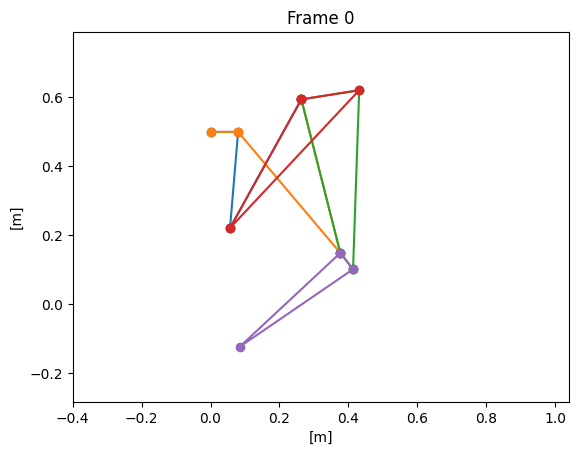

In [ ]:
# Animation of mechanism motion
global fig, ax, x_left, x_right, y_bottom, y_top, O_2, D, index_vec
# compute width and height of drawing canvas:
x_left   = -5 * r_2
y_bottom = -1.25 * max(r_2, r_4)
x_right  = r_2 + r_6 + 1.25 * L_2
y_top    = r_2 + r_6 + 1.25 * L_2

# Don't show figure until drawn explicitly:
plt.ioff()
# Initialize the figure
fig, ax = plt.subplots()

# Define the function to update the plot for each frame:
t_size = len(t)
# fraction of simulated frames in the animation:
frames = t_size/2

# Define point O_2 and D as ground link:
O_2 = np.array([0,0.5])
D = O_2 + rotate_vector(np.array([r_1, 0]), theta_0)

# time between frames
delta = int(np.floor(t_size / frames))
# index vector for frames        
index_vec = np.arange(0, t_size, delta)

# calculation and visualisation of the kinematics:
kinematics8bar(r_1, r_2, r_3, r_4, r_DC, r_6, r_7, r_8, theta_0, theta_C, theta_I, theta_2, dtheta_2, ddtheta_2, theta_3_init, theta_4_init, theta_6_init, theta_7_init, theta_f_init, theta_8_init, t)


# next step in the animation:
def update(frame):
    ax.cla()  # Clear the current axes -> every previous frame is cleared before drawing the next frame
    ax.axis('equal')  # Ensures 1 unit on x == 1 unit on y
    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')
    ax.set_xlim([x_left, x_right])
    ax.set_ylim([y_bottom, y_top])
    ax.set_title(f'Frame {frame}')

    # Calculate Cartesian coordinates using rotation matrix
    A = O_2 + rotate_vector(np.array([r_2, 0]), theta_2[frame])
    B1 = A + rotate_vector(np.array([r_3, 0]), theta_3[frame])
    B2 = D + rotate_vector(np.array([r_4, 0]), theta_4[frame])
    loop1 = np.array([O_2, A, B1, B2, D])
    ax.plot(loop1[:, 0], loop1[:, 1], '-o')

    A = O_2 + rotate_vector(np.array([r_2, 0]), theta_2[frame])
    E1 = A + rotate_vector(np.array([r_6, 0]), theta_6[frame])
    E2 = D + rotate_vector(np.array([L_1, 0]), theta_f[frame])
    loop2 = np.array([O_2, A, E1, E2, D])
    ax.plot(loop2[:, 0], loop2[:, 1], '-o')

    E = D + rotate_vector(np.array([L_1, 0]), theta_f[frame])
    F1 = E + rotate_vector(np.array([r_8, 0]), theta_8[frame])
    C = D + rotate_vector(np.array([r_DC, 0]), theta_4[frame] + theta_C)
    F2 = C + rotate_vector(np.array([r_7, 0]), theta_7[frame])
    loop3 = np.array([D, E, F1, F2, C, D])
    ax.plot(loop3[:, 0], loop3[:, 1], '-o')

    B = D + rotate_vector(np.array([r_4, 0]), theta_4[frame])
    loop4 = np.array([D,B,C,D])
    ax.plot(loop4[:, 0], loop4[:, 1], '-o')

    G = E + rotate_vector(np.array([L_2, 0]),  -(theta_I - theta_8[frame]))
    F = E + rotate_vector(np.array([r_8,0]), theta_8[frame])
    loop5 = np.array([E, F , G, E])
    ax.plot(loop5[:, 0], loop5[:, 1], '-o')
    return(ax)

# Update the animation
ani = FuncAnimation(fig, update, frames=len(index_vec), interval=50)


In [ ]:
''' 
    Calculation of the center of mass of a triangle formed by three points A, B, and C, 
    with respect to a reference point. 
    The function takes the coordinates of points A, B, and C, as well as the reference point, 
    and returns the coordinates of the center of mass of the triangle relative to the reference point.
'''

def centre_of_mass_triangle(A, B, C, reference_point): 
    # Calculate the centroid of the triangle formed by points A, B, and C
    A = A - reference_point
    B = B - reference_point
    C = C - reference_point
    x_com = (A[0] + B[0] + C[0]) / 3
    y_com = (A[1] + B[1] + C[1]) / 3
    return np.array([x_com, y_com, 0])

In [4]:
def get_linear_velocities(r_2, r_3, L_1, r_6, r_7, r_DC, theta_2, theta_3, theta_4, theta_6, theta_7, theta_8,  theta_C,
                          dtheta_2, dtheta_3, dtheta_4, dtheta_6, dtheta_7, dtheta_8,    D, B, C, E, G, F):
    
    v_A = np.cross([0,0,dtheta_2], [(r_2)*np.cos(theta_2), (r_2)*np.sin(theta_2), 0])
    v_C = np.cross([0,0,dtheta_4], [(r_DC)*np.cos(theta_4 + theta_C), (r_DC)*np.sin(theta_4 + theta_C), 0])
    v_E  = np.cross([0,0,dtheta_8], [(L_1)*np.cos(theta_8), (L_1)*np.sin(theta_8), 0])

    v_1 = np.cross([0,0,dtheta_2], [(r_2 / 2)*np.cos(theta_2), (r_2/2)*np.sin(theta_2), 0]) # lineair velocity of O2A
    v_2 = v_A + np.cross([0,0,dtheta_3], [(r_3 / 2)*np.cos(theta_3), (r_3/2)*np.sin(theta_3), 0]) # velocity of com of AB 
    v_3 = v_A + np.cross([0,0,dtheta_6], [(r_6 / 2)*np.cos(theta_6), (r_6/2)*np.sin(theta_6), 0]) #velocity of com of AE
    v_4 = np.cross([0,0, dtheta_4], centre_of_mass_triangle(D,B,C,D))
    v_5 = np.cross([0,0,dtheta_8], [(L_1/2)*np.cos(theta_8), (L_1/2)*np.sin(theta_8), 0])
    v_6 = v_C + np.cross([0,0, dtheta_7], [(r_7/2)*np.cos(theta_7), (r_7/2)*np.sin(theta_7)])
    v_7 = v_E + np.cross([0,0,dtheta_8], centre_of_mass_triangle(E,G,F,E))

    return [v_1, v_2, v_3, v_4, v_5, v_6, v_7]



In [3]:
def get_linear_acceleration(r_2, r_3, L_1, r_6, r_7, r_DC, theta_C, theta_2, dtheta_2, ddtheta_2, theta_3, dtheta_3, ddtheta_3, theta_4, dtheta_4,
                            ddtheta_4, theta_6, dtheta_6, ddtheta_6, theta_7, dtheta_7, ddtheta_7, theta_8, dtheta_8, ddtheta_8, D, B, C, E, G, F):
    
    [v_1, v_2, v_3, v_4, v_5, v_6, v_7] = get_linear_velocities(r_2, r_3, L_1, r_6, r_7, r_DC, theta_2, theta_3, theta_4, theta_6, theta_7, theta_8,  theta_C,
                                                                dtheta_2, dtheta_3, dtheta_4, dtheta_6, dtheta_7, dtheta_8,    D, B, C, E, G, F)
    
    a_A = np.cross([0,0,dtheta_2], np.cross([0,0,dtheta_2], [(r_2)*np.cos(theta_2), (r_2)*np.sin(theta_2), 0])) + np.cross([0,0,ddtheta_2], [(r_2)*np.cos(theta_2), (r_2)*np.sin(theta_2), 0])
    a_C = np.cross([0,0,dtheta_4], np.cross([0,0,dtheta_4], [(r_DC)*np.cos(theta_4 + theta_C), (r_DC)*np.sin(theta_4 + theta_C), 0])) + np.cross([0,0,ddtheta_4], [(r_DC)*np.cos(theta_4 + theta_C), (r_DC)*np.sin(theta_4 + theta_C), 0])
    a_E = np.cross([0,0,dtheta_8], np.cross([0,0,dtheta_8], [(L_1)*np.cos(theta_8), (L_1)*np.sin(theta_8), 0])) + np.cross([0,0,ddtheta_8], [(L_1)*np.cos(theta_8), (L_1)*np.sin(theta_8), 0])

    
    a_1 = np.cross([0,0,dtheta_2], v_1) + np.cross([0,0,ddtheta_2], [(r_2 / 2)*np.cos(theta_2), (r_2/2)*np.sin(theta_2), 0])
    a_2 = a_A + np.cross([0,0,dtheta_3], v_2) + np.cross([0,0,ddtheta_3], [(r_3 / 2)*np.cos(theta_3), (r_3/2)*np.sin(theta_3), 0])
    a_3 = a_A + np.cross([0,0,dtheta_6], v_3) + np.cross([0,0,ddtheta_6], [(r_6 / 2)*np.cos(theta_6), (r_6/2)*np.sin(theta_6), 0])
    a_4 = np.cross([0,0, dtheta_4], v_4) + np.cross([0,0, ddtheta_4], centre_of_mass_triangle(D,B,C,D))
    a_5 = np.cross([0,0,dtheta_8], v_5) + np.cross([0,0,ddtheta_8], [(L_1/2)*np.cos(theta_8), (L_1/2)*np.sin(theta_8), 0])
    a_6 = a_C + np.cross([0,0, dtheta_7], v_6) + np.cross([0,0, ddtheta_7], [(r_7/2)*np.cos(theta_7), (r_7/2)*np.sin(theta_7)])
    a_7 = a_E + np.cross([0,0,dtheta_8], v_7) + np.cross([0,0,ddtheta_8], centre_of_mass_triangle(E,G,F,E))

    return [a_1, a_2, a_3, a_4, a_5, a_6, a_7]

In [ ]:
v1 = np.zeros((len(theta_2), 3))
v2 = np.zeros((len(theta_2), 3))
v3 = np.zeros((len(theta_2), 3))
v4 = np.zeros((len(theta_2), 3))
v5 = np.zeros((len(theta_2), 3))
v6 = np.zeros((len(theta_2), 3))
v7 = np.zeros((len(theta_2), 3))

a1 = np.zeros((len(theta_2), 3))
a2 = np.zeros((len(theta_2), 3))
a3 = np.zeros((len(theta_2), 3))
a4 = np.zeros((len(theta_2), 3))
a5 = np.zeros((len(theta_2), 3))
a6 = np.zeros((len(theta_2), 3))
a7 = np.zeros((len(theta_2), 3))